# 02 — HCP Data Pipeline

This notebook creates compact processed HCP run bundles without retaining downloaded NIfTI files.

## Per-run pipeline

```text
HCP S3
  ↓
download one run into a temporary directory
  ↓
validate NIfTI, movement regressors, and EV files
  ↓
extract motion-cleaned Schaefer-300 ROI time series
  ↓
construct HRF-aligned hard and continuous targets
  ↓
save final processed bundle
  ↓
delete all temporary raw source files
```

## Final outputs

```text
X.npy
y.npy
y_hrf.npy
valid_mask.npy
task_mask.npy
frame_times.npy
roi_labels.tsv
events_long.tsv
source_manifest.tsv
metadata.json
```

Definitions:

```text
X      : [time, ROI] motion-cleaned ROI signals
y      : [time] hard labels; class 0 is baseline
y_hrf  : [time, condition] continuous HRF regressors
```


In [1]:
from __future__ import annotations

import json
import shutil
import tempfile
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable

import boto3
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from botocore.exceptions import (
    ClientError,
    NoCredentialsError,
    ProfileNotFound,
)
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.glm.first_level import compute_regressor
from nilearn.maskers import NiftiLabelsMasker

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 200)

print("boto3:", boto3.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("NiBabel:", nib.__version__)

boto3: 1.43.64
NumPy: 2.4.6
Pandas: 3.0.5
NiBabel: 5.4.2


## 1. Project paths

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hcp_ya_s1200"
    / "runs"
)

MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"
CACHE_DIR = PROJECT_ROOT / ".cache" / "nilearn"

for path in (
    PROCESSED_DATA_DIR,
    MANIFEST_DIR,
    CACHE_DIR,
):
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed runs:", PROCESSED_DATA_DIR)
print("Manifests:", MANIFEST_DIR)
print("Temporary raw files use the system temporary directory.")

Project root: /Users/srinivasgovindasurampudi/Projects/neurolens-rag
Processed runs: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs
Manifests: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/manifests
Temporary raw files use the system temporary directory.


## 2. Configuration

In [3]:
AWS_PROFILE = "hcp"
AWS_REGION = "us-east-1"

BUCKET_NAME = "hcp-openaccess"
DATASET_PREFIX = "HCP_1200"
DATASET_RELEASE = "HCP-YA-S1200"

SUBJECT_IDS = [
    "100307",
    "100408",
    "101006",
    "101107",
    "101309",
    "100206",
    "100610",
    "101410",
    "101915",
    "102008",
    "102109",
    "102311",
    "102513",
    "102614",
    "102715",
    "102816",
    "103010",
    "103111",
    "103212",
    "103414",
]

TASKS = [
    "MOTOR",
]

RUNS = [
    "LR",
    "RL",
]

ATLAS_N_ROIS = 300
ATLAS_NETWORKS = 7
ATLAS_RESOLUTION_MM = 2

DETREND = True
STANDARDIZE = "zscore_sample"
STANDARDIZE_CONFOUNDS = True
LOW_PASS_HZ = None
HIGH_PASS_HZ = None

HRF_MODEL = "spm"
HRF_HARD_LABEL_THRESHOLD_FRACTION = 0.10

OVERWRITE_PROCESSED_RUN = False
RUN_PIPELINE = True

print("Subjects:", SUBJECT_IDS)
print("Tasks:", TASKS)
print("Runs:", RUNS)
print("Planned runs:", len(SUBJECT_IDS) * len(TASKS) * len(RUNS))
print("RUN_PIPELINE:", RUN_PIPELINE)


Subjects: ['100307', '100408', '101006', '101107', '101309', '100206', '100610', '101410', '101915', '102008', '102109', '102311', '102513', '102614', '102715', '102816', '103010', '103111', '103212', '103414']
Tasks: ['MOTOR']
Runs: ['LR', 'RL']
Planned runs: 40
RUN_PIPELINE: True


## 3. Task event mappings

In [4]:
TASK_EVENT_FILE_MAPS: dict[str, dict[str, str]] = {
    "MOTOR": {
        "lh.txt": "left_hand",
        "rh.txt": "right_hand",
        "lf.txt": "left_foot",
        "rf.txt": "right_foot",
        "t.txt": "tongue",
    },
    "EMOTION": {
        "fear.txt": "faces",
        "neut.txt": "shapes",
    },
    "WM": {
        "0bk_body.txt": "0back_body",
        "0bk_faces.txt": "0back_faces",
        "0bk_places.txt": "0back_places",
        "0bk_tools.txt": "0back_tools",
        "2bk_body.txt": "2back_body",
        "2bk_faces.txt": "2back_faces",
        "2bk_places.txt": "2back_places",
        "2bk_tools.txt": "2back_tools",
    },
}

for task in TASKS:
    if task not in TASK_EVENT_FILE_MAPS:
        raise KeyError(f"No event mapping is defined for task {task!r}.")

TASK_EVENT_FILE_MAPS

{'MOTOR': {'lh.txt': 'left_hand',
  'rh.txt': 'right_hand',
  'lf.txt': 'left_foot',
  'rf.txt': 'right_foot',
  't.txt': 'tongue'},
 'EMOTION': {'fear.txt': 'faces', 'neut.txt': 'shapes'},
 'WM': {'0bk_body.txt': '0back_body',
  '0bk_faces.txt': '0back_faces',
  '0bk_places.txt': '0back_places',
  '0bk_tools.txt': '0back_tools',
  '2bk_body.txt': '2back_body',
  '2bk_faces.txt': '2back_faces',
  '2bk_places.txt': '2back_places',
  '2bk_tools.txt': '2back_tools'}}

## 4. Run data structures

In [5]:
@dataclass(frozen=True)
class RunSpec:
    subject_id: str
    task: str
    run: str

    @property
    def run_name(self) -> str:
        return f"tfMRI_{self.task}_{self.run}"

    @property
    def s3_prefix(self) -> str:
        return (
            f"{DATASET_PREFIX}/{self.subject_id}/"
            f"MNINonLinear/Results/{self.run_name}/"
        )

    @property
    def output_dir(self) -> Path:
        return (
            PROCESSED_DATA_DIR
            / f"sub-{self.subject_id}"
            / self.run_name
        )


@dataclass(frozen=True)
class LocalRunFiles:
    root: Path
    func_path: Path
    movement_path: Path
    events_dir: Path


@dataclass
class RunResult:
    subject_id: str
    task: str
    run: str
    status: str
    output_dir: str | None
    n_timepoints: int | None
    n_rois: int | None
    n_conditions: int | None
    message: str


def build_run_specs(
    subject_ids: Iterable[str],
    tasks: Iterable[str],
    runs: Iterable[str],
) -> list[RunSpec]:
    return [
        RunSpec(
            subject_id=str(subject_id),
            task=str(task),
            run=str(run),
        )
        for subject_id in subject_ids
        for task in tasks
        for run in runs
    ]


RUN_SPECS = build_run_specs(
    SUBJECT_IDS,
    TASKS,
    RUNS,
)

pd.DataFrame([asdict(spec) for spec in RUN_SPECS])

,subject_id,task,run
0,100307,MOTOR,LR
1,100307,MOTOR,RL
2,100408,MOTOR,LR
3,100408,MOTOR,RL
4,101006,MOTOR,LR
5,101006,MOTOR,RL
6,101107,MOTOR,LR
7,101107,MOTOR,RL
8,101309,MOTOR,LR
9,101309,MOTOR,RL


## 5. Bundle completion check

In [6]:
REQUIRED_BUNDLE_FILES = (
    "X.npy",
    "y.npy",
    "y_hrf.npy",
    "valid_mask.npy",
    "task_mask.npy",
    "frame_times.npy",
    "roi_labels.tsv",
    "events_long.tsv",
    "source_manifest.tsv",
    "metadata.json",
)


def processed_bundle_is_complete(spec: RunSpec) -> bool:
    return all(
        (spec.output_dir / filename).exists()
        for filename in REQUIRED_BUNDLE_FILES
    )

## 6. AWS connection

In [7]:
def create_hcp_s3_client(
    *,
    profile_name: str,
    region_name: str,
):
    try:
        session = boto3.Session(
            profile_name=profile_name,
            region_name=region_name,
        )
    except ProfileNotFound as error:
        raise RuntimeError(
            f"AWS profile {profile_name!r} was not found."
        ) from error

    credentials = session.get_credentials()

    if credentials is None:
        raise RuntimeError(
            f"No credentials resolved for profile {profile_name!r}."
        )

    client = session.client(
        "s3",
        region_name=region_name,
    )

    try:
        response = client.list_objects_v2(
            Bucket=BUCKET_NAME,
            Prefix=f"{DATASET_PREFIX}/",
            Delimiter="/",
            MaxKeys=5,
        )
    except NoCredentialsError as error:
        raise RuntimeError("AWS credentials were not found.") from error
    except ClientError as error:
        details = error.response.get("Error", {})
        code = details.get("Code", "Unknown")
        message = details.get("Message", "No AWS message.")
        raise RuntimeError(
            f"AWS request failed: {code}: {message}"
        ) from error

    print("Connected to:", BUCKET_NAME)
    print("Credential source:", credentials.method)
    print(
        "Example subject prefixes:",
        [
            item["Prefix"]
            for item in response.get("CommonPrefixes", [])
        ],
    )

    return client


s3 = create_hcp_s3_client(
    profile_name=AWS_PROFILE,
    region_name=AWS_REGION,
)

Connected to: hcp-openaccess
Credential source: shared-credentials-file
Example subject prefixes: ['HCP_1200/100206/', 'HCP_1200/100307/', 'HCP_1200/100408/', 'HCP_1200/100610/']


## 7. Remote file selection

In [8]:
def list_s3_objects(
    *,
    client,
    bucket: str,
    prefix: str,
) -> pd.DataFrame:
    paginator = client.get_paginator("list_objects_v2")
    rows: list[dict[str, Any]] = []

    for page in paginator.paginate(
        Bucket=bucket,
        Prefix=prefix,
    ):
        for item in page.get("Contents", []):
            rows.append(
                {
                    "key": item["Key"],
                    "size_bytes": int(item["Size"]),
                    "size_mb": float(item["Size"]) / (1024**2),
                    "last_modified": item["LastModified"],
                }
            )

    return pd.DataFrame(rows)


def select_required_run_objects(
    objects: pd.DataFrame,
    *,
    spec: RunSpec,
) -> pd.DataFrame:
    if objects.empty:
        return objects.copy()

    event_filenames = set(
        TASK_EVENT_FILE_MAPS[spec.task].keys()
    )

    func_suffix = f"/{spec.run_name}.nii.gz"

    is_func = objects["key"].str.endswith(func_suffix)
    is_motion = objects["key"].str.endswith(
        "/Movement_Regressors.txt"
    )
    is_modeled_event = objects["key"].map(
        lambda key: (
            "/EVs/" in key
            and Path(key).name in event_filenames
        )
    )

    selected = (
        objects.loc[
            is_func
            | is_motion
            | is_modeled_event
        ]
        .sort_values("key")
        .reset_index(drop=True)
    )

    if not selected["key"].str.endswith(func_suffix).any():
        raise FileNotFoundError(
            f"Functional NIfTI not found for {spec.s3_prefix}"
        )

    if not selected["key"].str.endswith(
        "/Movement_Regressors.txt"
    ).any():
        raise FileNotFoundError(
            f"Movement regressors not found for {spec.s3_prefix}"
        )

    found_event_names = {
        Path(key).name
        for key in selected["key"]
        if "/EVs/" in key
    }

    missing_events = event_filenames - found_event_names

    if missing_events:
        raise FileNotFoundError(
            "Missing modeled event files: "
            + ", ".join(sorted(missing_events))
        )

    return selected


def inspect_remote_run(
    *,
    client,
    spec: RunSpec,
) -> pd.DataFrame:
    objects = list_s3_objects(
        client=client,
        bucket=BUCKET_NAME,
        prefix=spec.s3_prefix,
    )

    selected = select_required_run_objects(
        objects,
        spec=spec,
    )

    if selected.empty:
        raise FileNotFoundError(
            f"No required S3 objects found for {spec.s3_prefix}"
        )

    return selected

## 8. Temporary download

In [9]:
def download_run_to_temporary_directory(
    *,
    client,
    spec: RunSpec,
    selected_objects: pd.DataFrame,
    temporary_root: Path,
) -> tuple[LocalRunFiles, pd.DataFrame]:
    records: list[dict[str, Any]] = []

    for row in selected_objects.itertuples(index=False):
        relative_path = Path(row.key).relative_to(
            spec.s3_prefix
        )

        local_path = temporary_root / relative_path
        local_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        print("Downloading:", row.key)

        client.download_file(
            BUCKET_NAME,
            row.key,
            str(local_path),
        )

        remote_size = int(row.size_bytes)
        local_size = local_path.stat().st_size

        records.append(
            {
                "s3_key": row.key,
                "remote_size_bytes": remote_size,
                "downloaded_size_bytes": local_size,
                "size_matches": local_size == remote_size,
            }
        )

    records_df = pd.DataFrame(records)

    if not records_df["size_matches"].all():
        raise RuntimeError(
            "At least one temporary download failed size verification."
        )

    local_files = LocalRunFiles(
        root=temporary_root,
        func_path=temporary_root / f"{spec.run_name}.nii.gz",
        movement_path=temporary_root / "Movement_Regressors.txt",
        events_dir=temporary_root / "EVs",
    )

    for required_path in (
        local_files.func_path,
        local_files.movement_path,
        local_files.events_dir,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                f"Temporary source missing: {required_path}"
            )

    return local_files, records_df

## 9. NIfTI and movement validation

In [10]:
def inspect_nifti(
    func_path: Path,
) -> tuple[nib.Nifti1Image, dict[str, Any]]:
    img = nib.load(func_path)

    if len(img.shape) != 4:
        raise ValueError(
            f"Expected 4D fMRI, got shape {img.shape}."
        )

    zooms = img.header.get_zooms()

    metadata = {
        "shape": [int(value) for value in img.shape],
        "n_timepoints": int(img.shape[-1]),
        "voxel_sizes_mm": [
            float(value)
            for value in zooms[:3]
        ],
        "tr_seconds": float(zooms[3]),
        "dtype": str(img.get_data_dtype()),
        "affine_is_finite": bool(
            np.isfinite(img.affine).all()
        ),
    }

    if not metadata["affine_is_finite"]:
        raise ValueError(
            "NIfTI affine contains non-finite values."
        )

    return img, metadata


def load_motion_regressors(
    movement_path: Path,
    *,
    expected_timepoints: int,
) -> np.ndarray:
    movement = np.loadtxt(movement_path)

    if movement.ndim == 1:
        movement = movement[:, None]

    if movement.shape[0] != expected_timepoints:
        raise ValueError(
            "Motion regressors and NIfTI have different "
            f"time dimensions: {movement.shape[0]} vs "
            f"{expected_timepoints}."
        )

    if not np.isfinite(movement).all():
        raise ValueError(
            "Movement regressors contain non-finite values."
        )

    return movement

## 10. Atlas and ROI extraction

In [11]:
def fetch_schaefer_atlas(
    *,
    n_rois: int,
    yeo_networks: int,
    resolution_mm: int,
):
    atlas = fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
        data_dir=str(CACHE_DIR / "atlases"),
    )

    labels = [
        label.decode("utf-8")
        if isinstance(label, bytes)
        else str(label)
        for label in atlas.labels
    ]

    if len(labels) == n_rois + 1:
        labels = labels[1:]

    if len(labels) != n_rois:
        raise ValueError(
            f"Atlas label count {len(labels)} "
            f"does not match {n_rois}."
        )

    return Path(atlas.maps), labels


def build_roi_masker(
    *,
    atlas_path: Path,
    roi_labels: list[str],
    tr_seconds: float,
) -> NiftiLabelsMasker:
    return NiftiLabelsMasker(
        labels_img=str(atlas_path),
        labels=roi_labels,
        background_label=0,
        standardize=STANDARDIZE,
        standardize_confounds=STANDARDIZE_CONFOUNDS,
        detrend=DETREND,
        low_pass=LOW_PASS_HZ,
        high_pass=HIGH_PASS_HZ,
        t_r=tr_seconds,
        resampling_target="data",
        memory=str(CACHE_DIR),
        memory_level=1,
        verbose=1,
    )


def extract_roi_timeseries(
    *,
    func_path: Path,
    movement: np.ndarray,
    atlas_path: Path,
    roi_labels: list[str],
    tr_seconds: float,
) -> np.ndarray:
    masker = build_roi_masker(
        atlas_path=atlas_path,
        roi_labels=roi_labels,
        tr_seconds=tr_seconds,
    )

    X = masker.fit_transform(
        str(func_path),
        confounds=movement,
    )

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    if X.ndim != 2:
        raise ValueError(
            f"ROI matrix must be 2D, got {X.shape}."
        )

    if not np.isfinite(X).all():
        raise ValueError(
            "ROI matrix contains non-finite values."
        )

    zero_variance_rois = np.where(
        X.std(axis=0) < 1e-8
    )[0]

    if len(zero_variance_rois) > 0:
        raise ValueError(
            "Zero-variance ROIs detected: "
            f"{zero_variance_rois.tolist()}"
        )

    return X

## 11. Event parsing

In [12]:
def read_hcp_event_file(
    path: Path,
    *,
    condition: str,
) -> pd.DataFrame:
    events = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["onset", "duration", "amplitude"],
        usecols=[0, 1, 2],
        dtype=float,
    )

    if events.empty:
        raise ValueError(
            f"Event file is empty: {path}"
        )

    values = events[
        ["onset", "duration", "amplitude"]
    ].to_numpy()

    if not np.isfinite(values).all():
        raise ValueError(
            f"Non-finite event values in {path}"
        )

    if (events["onset"] < 0).any():
        raise ValueError(
            f"Negative event onset in {path}"
        )

    if (events["duration"] <= 0).any():
        raise ValueError(
            f"Non-positive duration in {path}"
        )

    events["condition"] = condition
    events["source_file"] = path.name
    events["offset"] = (
        events["onset"]
        + events["duration"]
    )

    return events


def load_task_events(
    *,
    events_dir: Path,
    event_file_map: dict[str, str],
    run_duration_seconds: float,
    tr_seconds: float,
) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []

    for filename, condition in event_file_map.items():
        event_path = events_dir / filename

        if not event_path.exists():
            raise FileNotFoundError(
                f"Expected event file not found: {event_path}"
            )

        frames.append(
            read_hcp_event_file(
                event_path,
                condition=condition,
            )
        )

    events = (
        pd.concat(frames, ignore_index=True)
        .sort_values(["onset", "condition"])
        .reset_index(drop=True)
    )

    if (
        events["offset"].max()
        > run_duration_seconds + tr_seconds
    ):
        raise ValueError(
            "At least one event extends beyond the run."
        )

    return events

## 12. HRF targets

In [13]:
def events_to_hrf_matrix(
    events: pd.DataFrame,
    *,
    frame_times: np.ndarray,
    condition_names: list[str],
    hrf_model: str,
) -> np.ndarray:
    columns: list[np.ndarray] = []

    for condition in condition_names:
        condition_events = events[
            events["condition"] == condition
        ]

        experimental_condition = np.vstack(
            [
                condition_events["onset"].to_numpy(
                    dtype=float
                ),
                condition_events["duration"].to_numpy(
                    dtype=float
                ),
                condition_events["amplitude"].to_numpy(
                    dtype=float
                ),
            ]
        )

        regressor, regressor_names = compute_regressor(
            experimental_condition,
            hrf_model=hrf_model,
            frame_times=frame_times,
            con_id=condition,
        )

        if regressor.shape[1] != 1:
            raise ValueError(
                f"Expected one HRF regressor for "
                f"{condition}, got {regressor_names}."
            )

        columns.append(regressor[:, 0])

    y_hrf = np.column_stack(
        columns
    ).astype(np.float32)

    if not np.isfinite(y_hrf).all():
        raise ValueError(
            "HRF matrix contains non-finite values."
        )

    return y_hrf


def hrf_matrix_to_labels(
    y_hrf: np.ndarray,
    *,
    threshold_fraction: float,
) -> tuple[np.ndarray, np.ndarray, float]:
    threshold = (
        threshold_fraction
        * float(y_hrf.max())
    )

    winning_columns = np.argmax(
        y_hrf,
        axis=1,
    )

    winning_values = np.max(
        y_hrf,
        axis=1,
    )

    y = winning_columns.astype(
        np.int64
    ) + 1

    task_mask = winning_values > threshold
    y[~task_mask] = 0

    return y, task_mask, threshold


def build_targets(
    *,
    events: pd.DataFrame,
    n_timepoints: int,
    tr_seconds: float,
    condition_names: list[str],
) -> dict[str, Any]:
    frame_times = (
        np.arange(
            n_timepoints,
            dtype=np.float64,
        )
        * tr_seconds
    )

    y_hrf = events_to_hrf_matrix(
        events,
        frame_times=frame_times,
        condition_names=condition_names,
        hrf_model=HRF_MODEL,
    )

    y, task_mask, threshold = (
        hrf_matrix_to_labels(
            y_hrf,
            threshold_fraction=(
                HRF_HARD_LABEL_THRESHOLD_FRACTION
            ),
        )
    )

    valid_mask = np.ones(
        n_timepoints,
        dtype=bool,
    )

    condition_to_class = {
        condition: index + 1
        for index, condition
        in enumerate(condition_names)
    }

    class_to_condition = {
        0: "baseline",
        **{
            class_id: condition
            for condition, class_id
            in condition_to_class.items()
        },
    }

    return {
        "frame_times": frame_times.astype(np.float32),
        "y": y.astype(np.int64),
        "y_hrf": y_hrf.astype(np.float32),
        "valid_mask": valid_mask,
        "task_mask": task_mask,
        "hrf_threshold": threshold,
        "condition_names": condition_names,
        "condition_to_class": condition_to_class,
        "class_to_condition": class_to_condition,
    }

## 13. Bundle validation and saving

In [14]:
def validate_bundle(
    *,
    X: np.ndarray,
    targets: dict[str, Any],
    expected_rois: int,
) -> dict[str, Any]:
    y = targets["y"]
    y_hrf = targets["y_hrf"]
    valid_mask = targets["valid_mask"]
    task_mask = targets["task_mask"]

    n_timepoints = X.shape[0]

    if X.shape[1] != expected_rois:
        raise ValueError(
            f"Expected {expected_rois} ROIs, "
            f"got {X.shape[1]}."
        )

    if y.shape != (n_timepoints,):
        raise ValueError(
            f"y shape {y.shape} does not align with X."
        )

    if y_hrf.shape[0] != n_timepoints:
        raise ValueError(
            "y_hrf time dimension does not align with X."
        )

    if valid_mask.shape != (n_timepoints,):
        raise ValueError(
            "valid_mask does not align with X."
        )

    if task_mask.shape != (n_timepoints,):
        raise ValueError(
            "task_mask does not align with X."
        )

    if not np.isfinite(X).all():
        raise ValueError(
            "X contains non-finite values."
        )

    if not np.isfinite(y_hrf).all():
        raise ValueError(
            "y_hrf contains non-finite values."
        )

    return {
        "n_timepoints": int(n_timepoints),
        "n_rois": int(X.shape[1]),
        "n_conditions": int(y_hrf.shape[1]),
        "classes_present": [
            int(value)
            for value in np.unique(y)
        ],
        "task_volume_count": int(
            task_mask.sum()
        ),
        "baseline_volume_count": int(
            (y == 0).sum()
        ),
    }


def save_processed_bundle(
    *,
    spec: RunSpec,
    X: np.ndarray,
    targets: dict[str, Any],
    roi_labels: list[str],
    events: pd.DataFrame,
    nifti_metadata: dict[str, Any],
    validation_summary: dict[str, Any],
    acquisition_records: pd.DataFrame,
) -> Path:
    output_dir = spec.output_dir
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.save(
        output_dir / "X.npy",
        X.astype(np.float32),
    )

    np.save(
        output_dir / "y.npy",
        targets["y"].astype(np.int64),
    )

    np.save(
        output_dir / "y_hrf.npy",
        targets["y_hrf"].astype(np.float32),
    )

    np.save(
        output_dir / "valid_mask.npy",
        targets["valid_mask"].astype(bool),
    )

    np.save(
        output_dir / "task_mask.npy",
        targets["task_mask"].astype(bool),
    )

    np.save(
        output_dir / "frame_times.npy",
        targets["frame_times"].astype(np.float32),
    )

    pd.DataFrame(
        {
            "roi_index": np.arange(
                len(roi_labels)
            ),
            "roi_label": roi_labels,
        }
    ).to_csv(
        output_dir / "roi_labels.tsv",
        sep="\t",
        index=False,
    )

    events.to_csv(
        output_dir / "events_long.tsv",
        sep="\t",
        index=False,
    )

    acquisition_records.to_csv(
        output_dir / "source_manifest.tsv",
        sep="\t",
        index=False,
    )

    metadata = {
        "dataset_release": DATASET_RELEASE,
        "subject_id": spec.subject_id,
        "task": spec.task,
        "run": spec.run,
        "run_name": spec.run_name,
        "source_s3_prefix": spec.s3_prefix,
        "raw_files_retained": False,
        "atlas": {
            "name": "Schaefer2018",
            "n_rois": ATLAS_N_ROIS,
            "yeo_networks": ATLAS_NETWORKS,
            "resolution_mm": ATLAS_RESOLUTION_MM,
        },
        "roi_preprocessing": {
            "motion_regression": True,
            "confounds": "Movement_Regressors.txt",
            "detrend": DETREND,
            "standardize": STANDARDIZE,
            "standardize_confounds": STANDARDIZE_CONFOUNDS,
            "low_pass_hz": LOW_PASS_HZ,
            "high_pass_hz": HIGH_PASS_HZ,
        },
        "target_construction": {
            "hrf_model": HRF_MODEL,
            "hrf_threshold_fraction": (
                HRF_HARD_LABEL_THRESHOLD_FRACTION
            ),
            "hrf_threshold_value": targets[
                "hrf_threshold"
            ],
            "condition_names": targets[
                "condition_names"
            ],
            "condition_to_class": targets[
                "condition_to_class"
            ],
            "class_to_condition": {
                str(key): value
                for key, value
                in targets[
                    "class_to_condition"
                ].items()
            },
        },
        "nifti": nifti_metadata,
        "validation": validation_summary,
        "arrays": {
            "X": {
                "filename": "X.npy",
                "shape": list(X.shape),
                "dtype": "float32",
            },
            "y": {
                "filename": "y.npy",
                "shape": list(
                    targets["y"].shape
                ),
                "dtype": "int64",
            },
            "y_hrf": {
                "filename": "y_hrf.npy",
                "shape": list(
                    targets["y_hrf"].shape
                ),
                "dtype": "float32",
            },
        },
    }

    (
        output_dir / "metadata.json"
    ).write_text(
        json.dumps(
            metadata,
            indent=2,
        ),
        encoding="utf-8",
    )

    return output_dir

## 14. End-to-end processor

In [15]:
def process_one_run(
    *,
    spec: RunSpec,
    client,
    atlas_path: Path,
    roi_labels: list[str],
    overwrite_processed_run: bool,
) -> RunResult:
    print()
    print("=" * 80)
    print(
        f"Processing subject={spec.subject_id}, "
        f"task={spec.task}, run={spec.run}"
    )
    print("=" * 80)

    if (
        processed_bundle_is_complete(spec)
        and not overwrite_processed_run
    ):
        return RunResult(
            subject_id=spec.subject_id,
            task=spec.task,
            run=spec.run,
            status="skipped_existing_processed",
            output_dir=str(spec.output_dir),
            n_timepoints=None,
            n_rois=None,
            n_conditions=None,
            message="Complete processed bundle already exists.",
        )

    if (
        overwrite_processed_run
        and spec.output_dir.exists()
    ):
        shutil.rmtree(spec.output_dir)

    try:
        selected_objects = inspect_remote_run(
            client=client,
            spec=spec,
        )

        with tempfile.TemporaryDirectory(
            prefix=(
                f"neurolens_{spec.subject_id}_"
                f"{spec.run_name}_"
            )
        ) as temporary_directory:
            temporary_root = Path(
                temporary_directory
            )

            print(
                "Temporary processing directory:",
                temporary_root,
            )

            local_files, acquisition_records = (
                download_run_to_temporary_directory(
                    client=client,
                    spec=spec,
                    selected_objects=selected_objects,
                    temporary_root=temporary_root,
                )
            )

            _, nifti_metadata = inspect_nifti(
                local_files.func_path
            )

            n_timepoints = nifti_metadata[
                "n_timepoints"
            ]

            tr_seconds = nifti_metadata[
                "tr_seconds"
            ]

            movement = load_motion_regressors(
                local_files.movement_path,
                expected_timepoints=n_timepoints,
            )

            X = extract_roi_timeseries(
                func_path=local_files.func_path,
                movement=movement,
                atlas_path=atlas_path,
                roi_labels=roi_labels,
                tr_seconds=tr_seconds,
            )

            event_file_map = (
                TASK_EVENT_FILE_MAPS[
                    spec.task
                ]
            )

            events = load_task_events(
                events_dir=local_files.events_dir,
                event_file_map=event_file_map,
                run_duration_seconds=(
                    n_timepoints
                    * tr_seconds
                ),
                tr_seconds=tr_seconds,
            )

            targets = build_targets(
                events=events,
                n_timepoints=n_timepoints,
                tr_seconds=tr_seconds,
                condition_names=list(
                    event_file_map.values()
                ),
            )

            validation_summary = validate_bundle(
                X=X,
                targets=targets,
                expected_rois=ATLAS_N_ROIS,
            )

            output_dir = save_processed_bundle(
                spec=spec,
                X=X,
                targets=targets,
                roi_labels=roi_labels,
                events=events,
                nifti_metadata=nifti_metadata,
                validation_summary=(
                    validation_summary
                ),
                acquisition_records=(
                    acquisition_records
                ),
            )

        print(
            "Temporary NIfTI and source files deleted."
        )

        return RunResult(
            subject_id=spec.subject_id,
            task=spec.task,
            run=spec.run,
            status="completed",
            output_dir=str(output_dir),
            n_timepoints=validation_summary[
                "n_timepoints"
            ],
            n_rois=validation_summary[
                "n_rois"
            ],
            n_conditions=validation_summary[
                "n_conditions"
            ],
            message=(
                "Processed successfully; "
                "temporary source files deleted."
            ),
        )

    except Exception as error:
        return RunResult(
            subject_id=spec.subject_id,
            task=spec.task,
            run=spec.run,
            status="failed",
            output_dir=None,
            n_timepoints=None,
            n_rois=None,
            n_conditions=None,
            message=(
                f"{type(error).__name__}: {error}"
            ),
        )

## 15. Fetch atlas once

In [16]:
atlas_path, roi_labels = fetch_schaefer_atlas(
    n_rois=ATLAS_N_ROIS,
    yeo_networks=ATLAS_NETWORKS,
    resolution_mm=ATLAS_RESOLUTION_MM,
)

print("Atlas:", atlas_path)
print("ROI count:", len(roi_labels))
print("First labels:", roi_labels[:5])

[fetch_atlas_schaefer_2018] Dataset directory found: 
/Users/srinivasgovindasurampudi/Projects/neurolens-rag/.cache/nilearn/atlases/schaefer_2018

Atlas: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/.cache/nilearn/atlases/schaefer_2018/Schaefer2018_300Parcels_7Networks_order_FSLMNI152_2mm.nii.gz
ROI count: 300
First labels: ['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5']


## 16. Preview temporary download size

In [17]:
preview_frames: list[pd.DataFrame] = []

for spec in RUN_SPECS:
    preview = inspect_remote_run(
        client=s3,
        spec=spec,
    ).copy()

    preview["subject_id"] = spec.subject_id
    preview["task"] = spec.task
    preview["run"] = spec.run

    preview_frames.append(preview)

acquisition_preview_df = pd.concat(
    preview_frames,
    ignore_index=True,
)

preview_summary_df = (
    acquisition_preview_df
    .groupby(
        ["subject_id", "task", "run"],
        as_index=False,
    )
    .agg(
        files=("key", "count"),
        temporary_download_gb=(
            "size_bytes",
            lambda values: (
                values.sum() / (1024**3)
            ),
        ),
    )
)

preview_summary_df

,subject_id,task,run,files,temporary_download_gb
0,100206,MOTOR,LR,7,0.221409
1,100206,MOTOR,RL,7,0.221975
2,100307,MOTOR,LR,7,0.219111
3,100307,MOTOR,RL,7,0.219467
4,100408,MOTOR,LR,7,0.216501
5,100408,MOTOR,RL,7,0.217247
6,100610,MOTOR,LR,7,0.220972
7,100610,MOTOR,RL,7,0.221554
8,101006,MOTOR,LR,7,0.214462
9,101006,MOTOR,RL,7,0.214397


In [18]:
total_preview_gb = (
    acquisition_preview_df[
        "size_bytes"
    ].sum()
    / (1024**3)
)

print(
    f"Total selected remote size: "
    f"{total_preview_gb:.2f} GB"
)

display(
    acquisition_preview_df[
        [
            "subject_id",
            "task",
            "run",
            "size_mb",
            "key",
        ]
    ].sort_values(
        [
            "subject_id",
            "task",
            "run",
            "key",
        ]
    )
)

Total selected remote size: 8.78 GB


,subject_id,task,run,size_mb,key
70,100206,MOTOR,LR,0.000024,HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/lf.txt
71,100206,MOTOR,LR,0.000024,HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/lh.txt
72,100206,MOTOR,LR,0.000022,HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/rf.txt
73,100206,MOTOR,LR,0.000024,HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/rh.txt
74,100206,MOTOR,LR,0.000024,HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/t.txt
...,...,...,...,...,...
275,103414,MOTOR,RL,0.000024,HCP_1200/103414/MNINonLinear/Results/tfMRI_MOTOR_RL/EVs/rf.txt
276,103414,MOTOR,RL,0.000024,HCP_1200/103414/MNINonLinear/Results/tfMRI_MOTOR_RL/EVs/rh.txt
277,103414,MOTOR,RL,0.000024,HCP_1200/103414/MNINonLinear/Results/tfMRI_MOTOR_RL/EVs/t.txt
278,103414,MOTOR,RL,0.036022,HCP_1200/103414/MNINonLinear/Results/tfMRI_MOTOR_RL/Movement_Regressors.txt


## 17. Run pipeline

In [19]:
if RUN_PIPELINE:
    run_results: list[RunResult] = []

    for spec in RUN_SPECS:
        result = process_one_run(
            spec=spec,
            client=s3,
            atlas_path=atlas_path,
            roi_labels=roi_labels,
            overwrite_processed_run=(
                OVERWRITE_PROCESSED_RUN
            ),
        )

        run_results.append(result)

        print(
            result.status,
            result.message,
        )

    run_results_df = pd.DataFrame(
        [
            asdict(result)
            for result in run_results
        ]
    )

    display(run_results_df)
else:
    run_results_df = pd.DataFrame()

    print("Pipeline not executed.")
    print(
        "Review the preview, then set "
        "RUN_PIPELINE = True."
    )


Processing subject=100307, task=MOTOR, run=LR
skipped_existing_processed Complete processed bundle already exists.

Processing subject=100307, task=MOTOR, run=RL
skipped_existing_processed Complete processed bundle already exists.

Processing subject=100408, task=MOTOR, run=LR
skipped_existing_processed Complete processed bundle already exists.

Processing subject=100408, task=MOTOR, run=RL
skipped_existing_processed Complete processed bundle already exists.

Processing subject=101006, task=MOTOR, run=LR
skipped_existing_processed Complete processed bundle already exists.

Processing subject=101006, task=MOTOR, run=RL
skipped_existing_processed Complete processed bundle already exists.

Processing subject=101107, task=MOTOR, run=LR
skipped_existing_processed Complete processed bundle already exists.

Processing subject=101107, task=MOTOR, run=RL
skipped_existing_processed Complete processed bundle already exists.

Processing subject=101309, task=MOTOR, run=LR
skipped_existing_processe

Downloading: HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/rf.txt
Downloading: HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/rh.txt


Downloading: HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs/t.txt
Downloading: HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/Movement_Regressors.txt


Downloading: HCP_1200/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR.nii.gz


[NiftiLabelsMasker.wrapped] Loading regions from 
'/Users/srinivasgovindasurampudi/Projects/neurolens-rag/.cache/nilearn/atlases/schaefer_2018/Schaefer2018_300Parcel
s_7Networks_order_FSLMNI152_2mm.nii.gz'

...

[NiftiLabelsMasker.wrapped] Loading data from 
'/var/folders/r4/spznqqj55yjg7yv8f_ym1pmm0000gn/T/neurolens_103414_tfMRI_MOTOR_RL_saugtrh6/tfMRI_MOTOR_RL.nii.gz'

[NiftiLabelsMasker.wrapped] Extracting region signals

[NiftiLabelsMasker.wrapped] Cleaning extracted signals

______________________________________________filter_and_extract - 10.2s, 0.2min
Temporary NIfTI and source files deleted.
completed Processed successfully; temporary source files deleted.


,subject_id,task,run,status,output_dir,n_timepoints,n_rois,n_conditions,message
0,100307,MOTOR,LR,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100307/tfMRI_MOTOR_LR,NaN,NaN,NaN,Complete processed bundle already exists.
1,100307,MOTOR,RL,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100307/tfMRI_MOTOR_RL,NaN,NaN,NaN,Complete processed bundle already exists.
2,100408,MOTOR,LR,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100408/tfMRI_MOTOR_LR,NaN,NaN,NaN,Complete processed bundle already exists.
3,100408,MOTOR,RL,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100408/tfMRI_MOTOR_RL,NaN,NaN,NaN,Complete processed bundle already exists.
4,101006,MOTOR,LR,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-101006/tfMRI_MOTOR_LR,NaN,NaN,NaN,Complete processed bundle already exists.
5,101006,MOTOR,RL,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-101006/tfMRI_MOTOR_RL,NaN,NaN,NaN,Complete processed bundle already exists.
6,101107,MOTOR,LR,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-101107/tfMRI_MOTOR_LR,NaN,NaN,NaN,Complete processed bundle already exists.
7,101107,MOTOR,RL,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-101107/tfMRI_MOTOR_RL,NaN,NaN,NaN,Complete processed bundle already exists.
8,101309,MOTOR,LR,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-101309/tfMRI_MOTOR_LR,NaN,NaN,NaN,Complete processed bundle already exists.
9,101309,MOTOR,RL,skipped_existing_processed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-101309/tfMRI_MOTOR_RL,NaN,NaN,NaN,Complete processed bundle already exists.


## 18. Save processed-run manifest

In [20]:
if not run_results_df.empty:
    run_manifest_path = (
        MANIFEST_DIR
        / "hcp_s1200_processed_runs.csv"
    )

    if run_manifest_path.exists():
        existing_manifest = pd.read_csv(
            run_manifest_path
        )

        combined_manifest = pd.concat(
            [
                existing_manifest,
                run_results_df,
            ],
            ignore_index=True,
        )

        combined_manifest = (
            combined_manifest
            .drop_duplicates(
                subset=[
                    "subject_id",
                    "task",
                    "run",
                ],
                keep="last",
            )
            .sort_values(
                [
                    "subject_id",
                    "task",
                    "run",
                ]
            )
            .reset_index(drop=True)
        )
    else:
        combined_manifest = (
            run_results_df.copy()
        )

    combined_manifest.to_csv(
        run_manifest_path,
        index=False,
    )

    print("Saved:", run_manifest_path)
    display(combined_manifest)
else:
    print(
        "No run manifest saved because "
        "the pipeline has not executed."
    )

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/manifests/hcp_s1200_processed_runs.csv


,subject_id,task,run,status,output_dir,n_timepoints,n_rois,n_conditions,message
0,100307,EMOTION,LR,failed,NaN,NaN,NaN,NaN,ValueError: At least one event extends beyond the run.
1,100307,EMOTION,RL,failed,NaN,NaN,NaN,NaN,ValueError: At least one event extends beyond the run.
2,100307,MOTOR,LR,completed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100307/tfMRI_MOTOR_LR,284.0,300.0,5.0,Processed successfully; temporary source files deleted.
3,100307,MOTOR,RL,completed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100307/tfMRI_MOTOR_RL,284.0,300.0,5.0,Processed successfully; temporary source files deleted.
4,100408,EMOTION,LR,failed,NaN,NaN,NaN,NaN,ValueError: At least one event extends beyond the run.
5,100408,EMOTION,RL,failed,NaN,NaN,NaN,NaN,ValueError: At least one event extends beyond the run.
6,100408,MOTOR,LR,completed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100408/tfMRI_MOTOR_LR,284.0,300.0,5.0,Processed successfully; temporary source files deleted.
7,100408,MOTOR,RL,completed,/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/runs/sub-100408/tfMRI_MOTOR_RL,284.0,300.0,5.0,Processed successfully; temporary source files deleted.
8,101006,EMOTION,LR,failed,NaN,NaN,NaN,NaN,ValueError: At least one event extends beyond the run.
9,101006,EMOTION,RL,failed,NaN,NaN,NaN,NaN,ValueError: At least one event extends beyond the run.


## 19. Verify completed bundles

In [21]:
completed_specs = [
    spec
    for spec in RUN_SPECS
    if processed_bundle_is_complete(spec)
]

verification_rows: list[dict[str, Any]] = []

for spec in completed_specs:
    X = np.load(
        spec.output_dir / "X.npy",
        mmap_mode="r",
    )

    y = np.load(
        spec.output_dir / "y.npy",
        mmap_mode="r",
    )

    y_hrf = np.load(
        spec.output_dir / "y_hrf.npy",
        mmap_mode="r",
    )

    metadata = json.loads(
        (
            spec.output_dir
            / "metadata.json"
        ).read_text(
            encoding="utf-8"
        )
    )

    retained_nifti_files = list(
        spec.output_dir.rglob("*.nii*")
    )

    verification_rows.append(
        {
            "subject_id": spec.subject_id,
            "task": spec.task,
            "run": spec.run,
            "X_shape": tuple(X.shape),
            "y_shape": tuple(y.shape),
            "y_hrf_shape": tuple(y_hrf.shape),
            "classes": np.unique(y).tolist(),
            "raw_files_retained": metadata[
                "raw_files_retained"
            ],
            "retained_nifti_count": len(
                retained_nifti_files
            ),
            "bundle_valid": bool(
                X.shape[0]
                == y.shape[0]
                == y_hrf.shape[0]
                and len(
                    retained_nifti_files
                ) == 0
            ),
        }
    )

verification_df = pd.DataFrame(
    verification_rows
)

verification_df

,subject_id,task,run,X_shape,y_shape,y_hrf_shape,classes,raw_files_retained,retained_nifti_count,bundle_valid
0,100307,MOTOR,LR,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
1,100307,MOTOR,RL,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
2,100408,MOTOR,LR,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
3,100408,MOTOR,RL,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
4,101006,MOTOR,LR,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
5,101006,MOTOR,RL,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
6,101107,MOTOR,LR,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
7,101107,MOTOR,RL,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
8,101309,MOTOR,LR,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True
9,101309,MOTOR,RL,"(284, 300)","(284,)","(284, 5)","[0, 1, 2, 3, 4, 5]",False,0,True


## 20. Inspect one bundle

In [22]:
if completed_specs:
    example_spec = completed_specs[0]

    X = np.load(
        example_spec.output_dir
        / "X.npy",
        mmap_mode="r",
    )

    y = np.load(
        example_spec.output_dir
        / "y.npy",
        mmap_mode="r",
    )

    y_hrf = np.load(
        example_spec.output_dir
        / "y_hrf.npy",
        mmap_mode="r",
    )

    metadata = json.loads(
        (
            example_spec.output_dir
            / "metadata.json"
        ).read_text(
            encoding="utf-8"
        )
    )

    print("Example run:", example_spec)
    print("X:", X.shape, X.dtype)
    print("y:", y.shape, y.dtype)
    print("y classes:", np.unique(y))
    print("y_hrf:", y_hrf.shape, y_hrf.dtype)
    print(
        "Raw files retained:",
        metadata["raw_files_retained"],
    )
else:
    print(
        "No complete processed bundle found."
    )

Example run: RunSpec(subject_id='100307', task='MOTOR', run='LR')
X: (284, 300) float32
y: (284,) int64
y classes: [0 1 2 3 4 5]
y_hrf: (284, 5) float32
Raw files retained: False


## 21. Quick QC

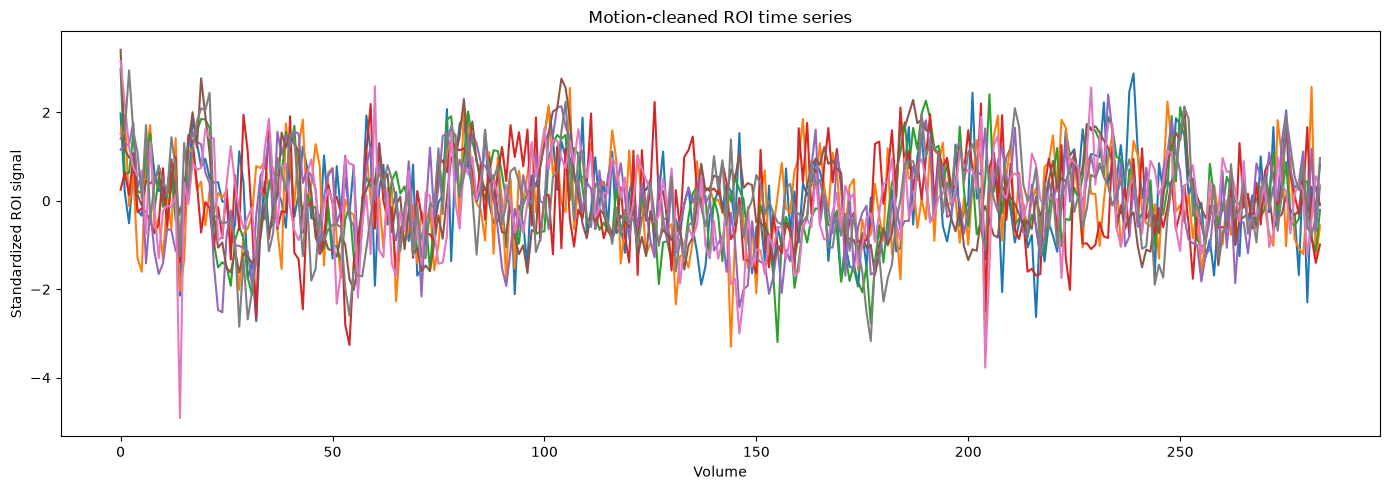

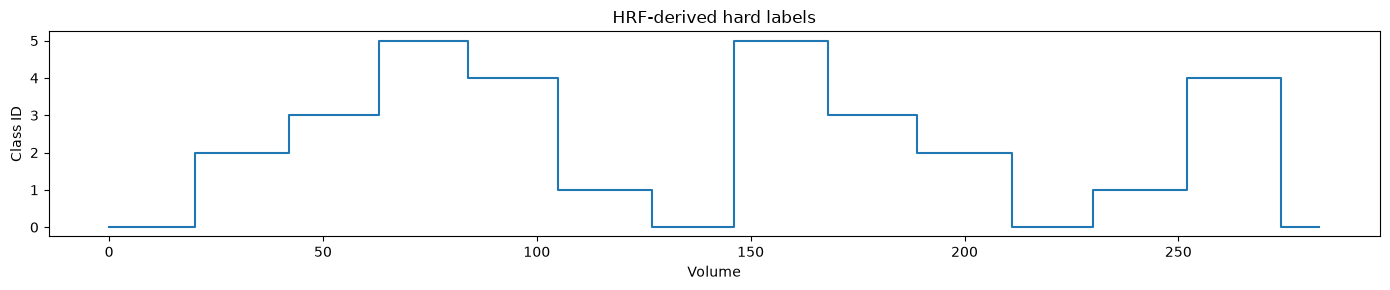

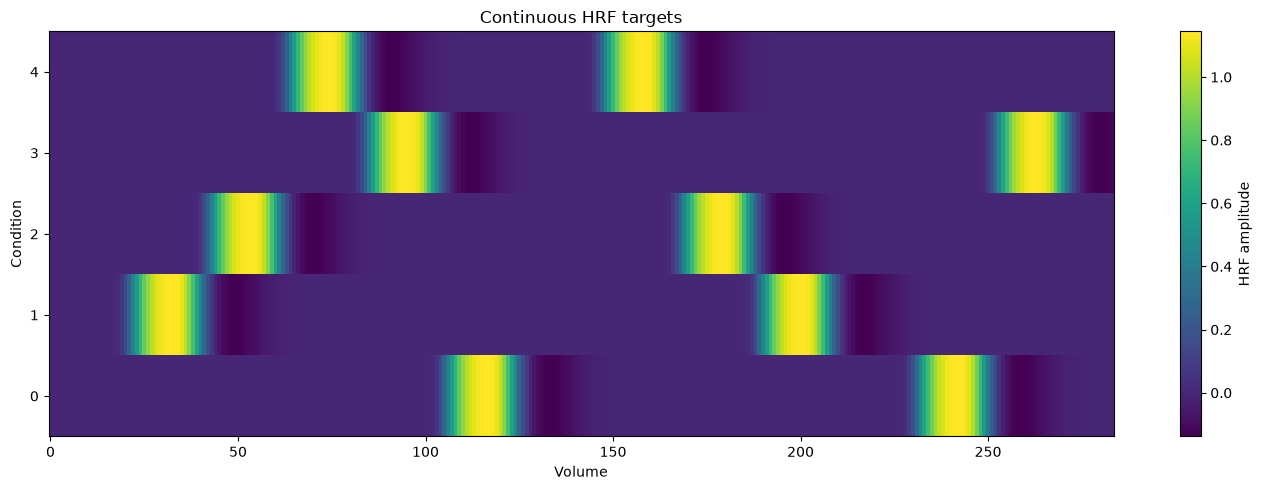

In [23]:
if completed_specs:
    plt.figure(figsize=(14, 5))
    plt.plot(
        np.asarray(
            X[:, :8]
        )
    )
    plt.xlabel("Volume")
    plt.ylabel("Standardized ROI signal")
    plt.title("Motion-cleaned ROI time series")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 3))
    plt.step(
        np.arange(len(y)),
        np.asarray(y),
        where="post",
    )
    plt.xlabel("Volume")
    plt.ylabel("Class ID")
    plt.title("HRF-derived hard labels")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.imshow(
        np.asarray(y_hrf).T,
        aspect="auto",
        origin="lower",
    )
    plt.xlabel("Volume")
    plt.ylabel("Condition")
    plt.title("Continuous HRF targets")
    plt.colorbar(label="HRF amplitude")
    plt.tight_layout()
    plt.show()

## 22. Scaling

After one run is verified, expand:

```python
SUBJECT_IDS = [
    "100307",
    "100408",
    "101006",
    "101107",
    "101309",
]

TASKS = [
    "MOTOR",
    "EMOTION",
]

RUNS = [
    "LR",
    "RL",
]
```

Runs are processed sequentially, so only one NIfTI exists temporarily at a time.

The next notebook will consume only final bundles:

```text
03_dataset_dataloaders.ipynb
```
